  Region  Year        Season   Avg_Temp  Failure_Count    Temp_Range  \
0   EAST  2020       MONSOON  22.753333              3  (19.5, 26.2]   
1   EAST  2020  POST-MONSOON  21.810000              2  (19.5, 26.2]   
2   EAST  2020        SUMMER  26.060000              3  (19.5, 26.2]   
3   EAST  2020        WINTER  17.421667              6  (12.9, 19.5]   
4   EAST  2021       MONSOON  25.632222              9  (19.5, 26.2]   

  Failure_Category  
0              LOW  
1              LOW  
2              LOW  
3              LOW  
4              LOW  

REGION : EAST


<Figure size 1000x600 with 0 Axes>

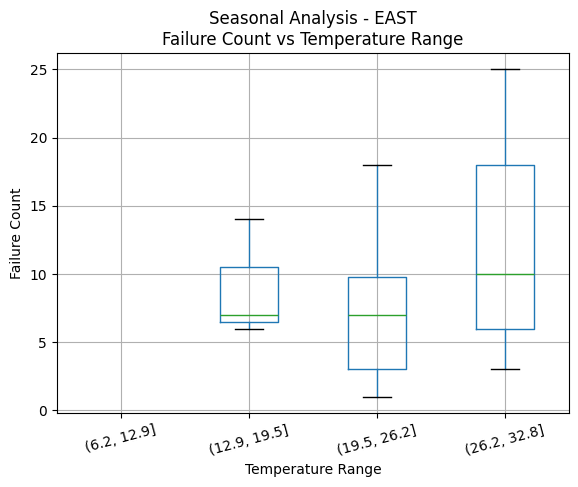


REGION : NORTH1


<Figure size 1000x600 with 0 Axes>

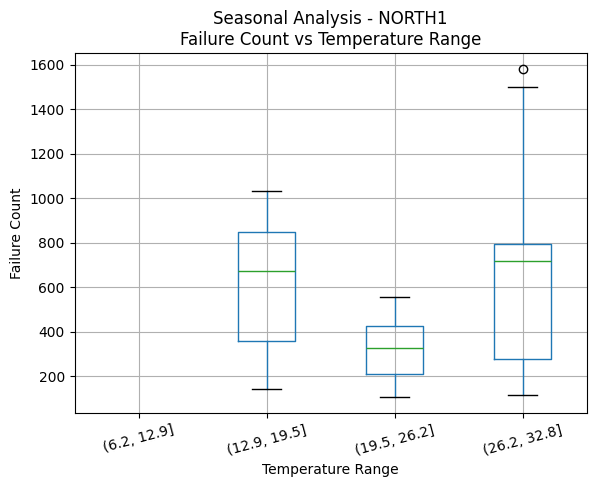


REGION : NORTH2


<Figure size 1000x600 with 0 Axes>

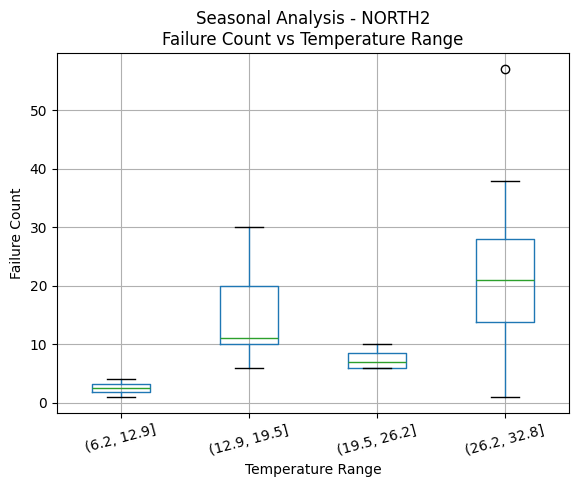


REGION : SOUTH


<Figure size 1000x600 with 0 Axes>

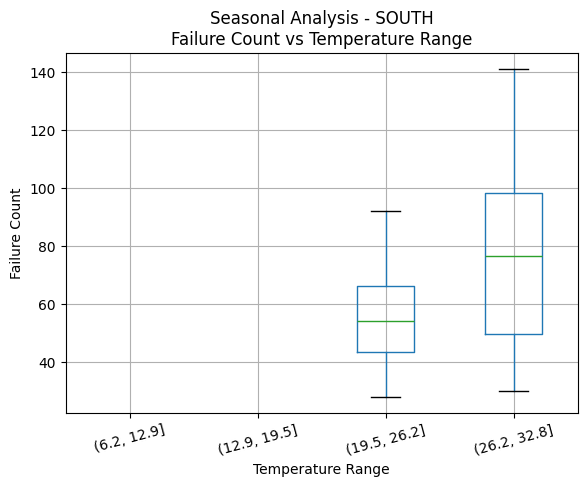


REGION : WEST1


<Figure size 1000x600 with 0 Axes>

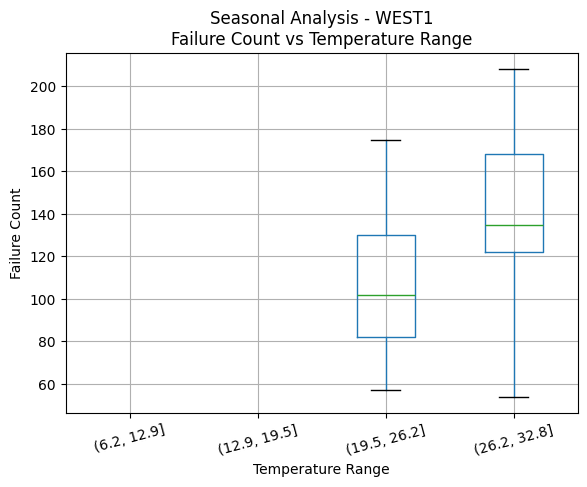


REGION : WEST2


<Figure size 1000x600 with 0 Axes>

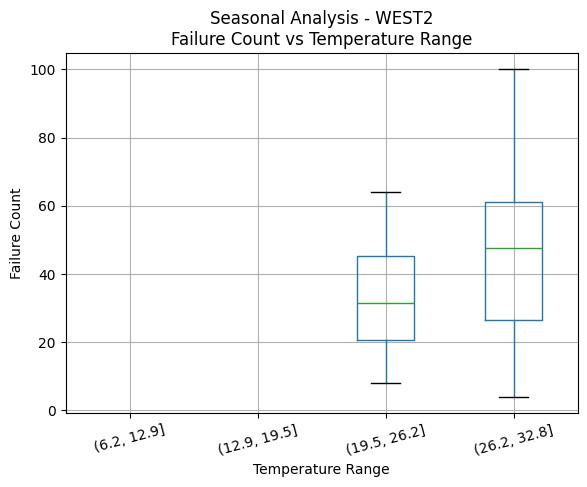


SEASONAL REGION-WISE ANALYSIS COMPLETED
ALL RESULTS EXPORTED SUCCESSFULLY


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau,
    f_oneway,
    kruskal,
    chi2_contingency
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import os

# ==========================================
# CREATE OUTPUT DIRECTORY
# ==========================================

output_dir = r"Temperature_Analysis\Seasonal_Analysis\Region-Wise"

os.makedirs(output_dir, exist_ok=True)

# ==========================================
# LOAD TEMPERATURE DATASET
# ==========================================

temp_df = pd.read_excel(
    r"C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Temperature_And_Quantity_Analysis.xlsx",
    sheet_name='Temp_Season_Region'
)


failure_df = pd.read_excel(r"C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Temperature_And_Quantity_Analysis.xlsx",sheet_name='Qty_Season_Region')

# ==========================================
# MERGE DATASETS
# ==========================================

df = pd.merge(
    temp_df,
    failure_df,
    on=['Region', 'Year', 'Season'],
    how='inner'
)

# ==========================================
# RENAME COLUMNS
# ==========================================

df.rename(columns={
    'Avg_Temperature': 'Avg_Temp',
    'Absolute_Quantity': 'Failure_Count'
}, inplace=True)

# ==========================================
# CLEAN REGION COLUMN
# ==========================================

df['Region'] = (
    df['Region']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
    .str.upper()
)

# ==========================================
# CLEAN SEASON COLUMN
# ==========================================

df['Season'] = (
    df['Season']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
    .str.upper()
)

# ==========================================
# CREATE TEMPERATURE RANGES
# ==========================================

df['Temp_Range'] = pd.cut(
    df['Avg_Temp'],
    bins=4,
    precision=1
)

# ==========================================
# CREATE FAILURE CATEGORIES
# ==========================================

df['Failure_Category'] = pd.cut(
    df['Failure_Count'],
    bins=4,
    labels=[
        'LOW',
        'MODERATE',
        'HIGH',
        'VERY_HIGH'
    ]
)

# ==========================================
# DISPLAY DATA
# ==========================================

print(df.head())

# ==========================================
# STORE RESULTS
# ==========================================

pearson_results = []
spearman_results = []
kendall_results = []
anova_results = []
kruskal_results = []
chi_results = []
cramers_results = []
tukey_all_results = []

# ==========================================
# REGION LIST
# ==========================================

regions = df['Region'].unique()

# ==========================================
# LOOP THROUGH EACH REGION
# ==========================================

for region in regions:

    print(f"\n==============================")
    print(f"REGION : {region}")
    print(f"==============================")

    region_df = df[df['Region'] == region]

    # ======================================
    # CHECK DATA VALIDITY
    # ======================================

    if len(region_df) < 2:
        print("Not enough data")
        continue

    if (
        region_df['Avg_Temp'].nunique() <= 1 or
        region_df['Failure_Count'].nunique() <= 1
    ):
        print("Constant values detected")
        continue

    # ======================================
    # PEARSON CORRELATION
    # ======================================

    pearson_corr, pearson_p = pearsonr(
        region_df['Avg_Temp'],
        region_df['Failure_Count']
    )

    pearson_results.append({
        'Region': region,
        'Pearson_Correlation': round(pearson_corr, 4),
        'P_Value': round(pearson_p, 6)
    })

    # ======================================
    # SPEARMAN CORRELATION
    # ======================================

    spearman_corr, spearman_p = spearmanr(
        region_df['Avg_Temp'],
        region_df['Failure_Count']
    )

    spearman_results.append({
        'Region': region,
        'Spearman_Correlation': round(spearman_corr, 4),
        'P_Value': round(spearman_p, 6)
    })

    # ======================================
    # KENDALL TAU
    # ======================================

    kendall_corr, kendall_p = kendalltau(
        region_df['Avg_Temp'],
        region_df['Failure_Count']
    )

    kendall_results.append({
        'Region': region,
        'Kendall_Tau': round(kendall_corr, 4),
        'P_Value': round(kendall_p, 6)
    })

    # ======================================
    # CREATE GROUPS FOR ANOVA/KRUSKAL
    # ======================================

    groups = []

    temp_ranges = region_df['Temp_Range'].unique()

    for temp_range in temp_ranges:

        group_data = region_df[
            region_df['Temp_Range'] == temp_range
        ]['Failure_Count']

        if len(group_data) < 2:
            continue

        groups.append(group_data)

    # ======================================
    # ANOVA
    # ======================================

    if len(groups) >= 2:

        anova_f, anova_p = f_oneway(*groups)

        anova_results.append({
            'Region': region,
            'F_Statistic': round(anova_f, 4),
            'P_Value': round(anova_p, 6)
        })

        # ==================================
        # KRUSKAL WALLIS
        # ==================================

        kruskal_h, kruskal_p = kruskal(*groups)

        kruskal_results.append({
            'Region': region,
            'H_Statistic': round(kruskal_h, 4),
            'P_Value': round(kruskal_p, 6)
        })

        # ==================================
        # TUKEY HSD
        # ==================================

        try:

            tukey = pairwise_tukeyhsd(
                endog=region_df['Failure_Count'],
                groups=region_df['Temp_Range'],
                alpha=0.05
            )

            tukey_df = pd.DataFrame(
                data=tukey._results_table.data[1:],
                columns=tukey._results_table.data[0]
            )

            tukey_df['Region'] = region

            tukey_all_results.append(tukey_df)

        except:
            print(f"Tukey failed for {region}")

    # ======================================
    # CHI SQUARE + CRAMER'S V
    # ======================================

    contingency_table = pd.crosstab(
        region_df['Temp_Range'],
        region_df['Failure_Category']
    )

    if (
        contingency_table.shape[0] >= 2 and
        contingency_table.shape[1] >= 2
    ):

        chi2, chi_p, dof, expected = chi2_contingency(
            contingency_table
        )

        chi_results.append({
            'Region': region,
            'Chi2_Statistic': round(chi2, 4),
            'P_Value': round(chi_p, 6),
            'Degrees_of_Freedom': dof
        })

        # ==================================
        # CRAMER'S V
        # ==================================

        n = contingency_table.sum().sum()

        min_dimension = min(
            contingency_table.shape[0] - 1,
            contingency_table.shape[1] - 1
        )

        cramers_v = np.sqrt(
            chi2 / (n * min_dimension)
        )

        cramers_results.append({
            'Region': region,
            'Cramers_V': round(cramers_v, 4),
            'P_Value': round(chi_p, 6)
        })

    # ======================================
    # BOXPLOT
    # ======================================

    plt.figure(figsize=(10,6))

    region_df.boxplot(
        column='Failure_Count',
        by='Temp_Range',
        rot=15
    )

    plt.title(
        f"Seasonal Analysis - {region}\n"
        f"Failure Count vs Temperature Range"
    )

    plt.suptitle("")

    plt.xlabel("Temperature Range")
    plt.ylabel("Failure Count")

    plt.grid(True)

    plt.show()

# ==========================================
# CONVERT TO DATAFRAMES
# ==========================================

pearson_df = pd.DataFrame(pearson_results)
spearman_df = pd.DataFrame(spearman_results)
kendall_df = pd.DataFrame(kendall_results)
anova_df = pd.DataFrame(anova_results)
kruskal_df = pd.DataFrame(kruskal_results)
chi_df = pd.DataFrame(chi_results)
cramers_df = pd.DataFrame(cramers_results)

# ==========================================
# TUKEY DATAFRAME
# ==========================================

if len(tukey_all_results) > 0:

    tukey_df_final = pd.concat(
        tukey_all_results,
        ignore_index=True
    )

else:

    tukey_df_final = pd.DataFrame()

# ==========================================
# EXPORT RESULTS
# ==========================================

pearson_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Pearson.xlsx",
    index=False
)

spearman_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Spearman.xlsx",
    index=False
)

kendall_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Kendall.xlsx",
    index=False
)

anova_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_ANOVA.xlsx",
    index=False
)

kruskal_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Kruskal.xlsx",
    index=False
)

tukey_df_final.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Tukey_HSD.xlsx",
    index=False
)

chi_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Chi_Square.xlsx",
    index=False
)

cramers_df.to_excel(
    rf"{output_dir}\Seasonal_Regionwise_Cramers_V.xlsx",
    index=False
)

print("\n===================================")
print("SEASONAL REGION-WISE ANALYSIS COMPLETED")
print("ALL RESULTS EXPORTED SUCCESSFULLY")
print("===================================")

   SLoc  Year        Season   Avg_Temp  Failure_Count    Temp_Range  \
0  5001  2020       MONSOON  26.543000             50  (17.5, 26.7]   
1  5001  2020  POST-MONSOON  25.783548             33  (17.5, 26.7]   
2  5001  2020        SUMMER  27.735116             43  (26.7, 36.0]   
3  5001  2020        WINTER  23.773636             55  (17.5, 26.7]   
4  5001  2021       MONSOON  26.315532             47  (17.5, 26.7]   

  Failure_Category  
0              LOW  
1              LOW  
2              LOW  
3              LOW  
4              LOW  

SLOC : 5001


<Figure size 1000x600 with 0 Axes>

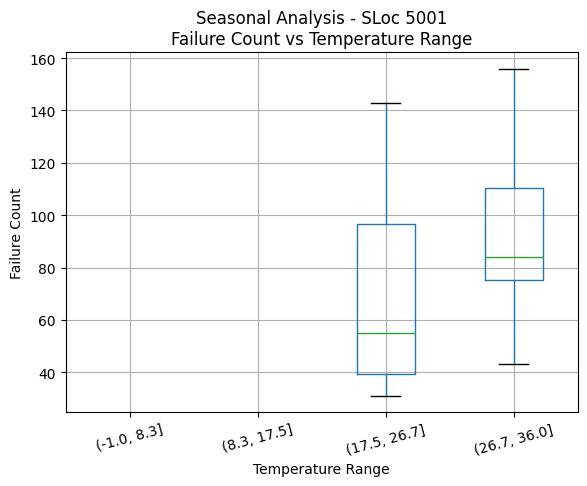


SLOC : 5002


<Figure size 1000x600 with 0 Axes>

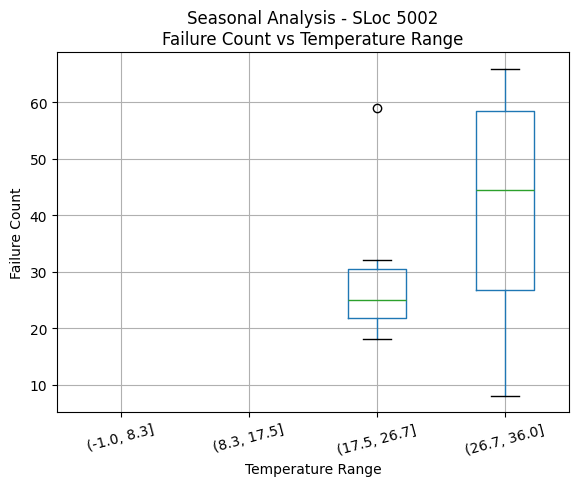


SLOC : 5003


<Figure size 1000x600 with 0 Axes>

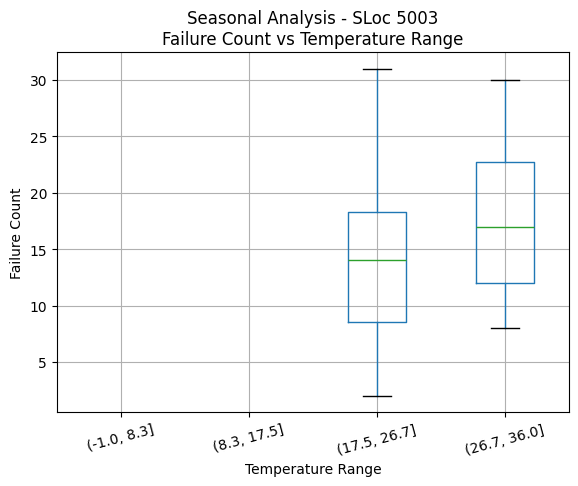


SLOC : 5004


<Figure size 1000x600 with 0 Axes>

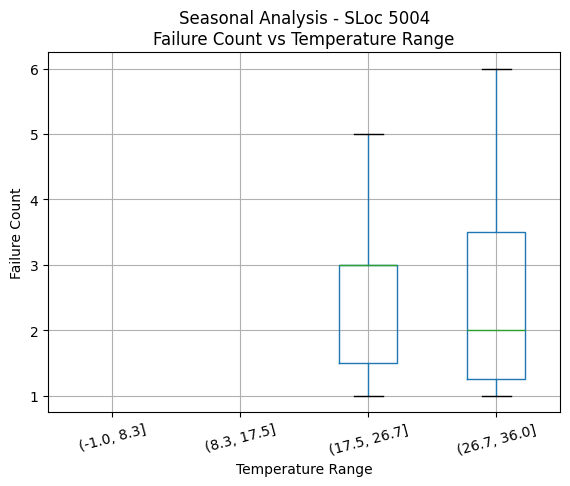


SLOC : 5005


<Figure size 1000x600 with 0 Axes>

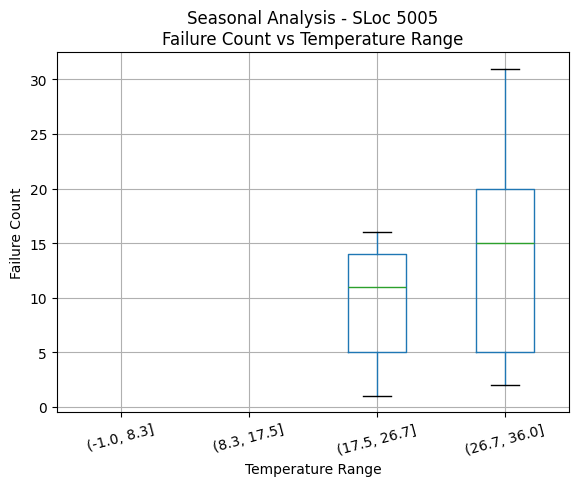


SLOC : 5006


<Figure size 1000x600 with 0 Axes>

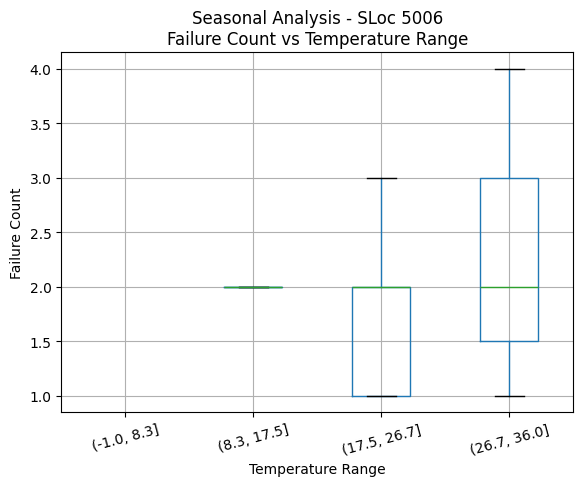


SLOC : 5007


<Figure size 1000x600 with 0 Axes>

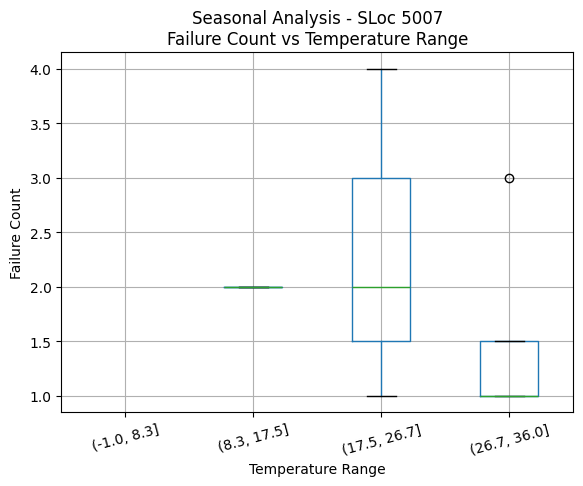


SLOC : 5008


<Figure size 1000x600 with 0 Axes>

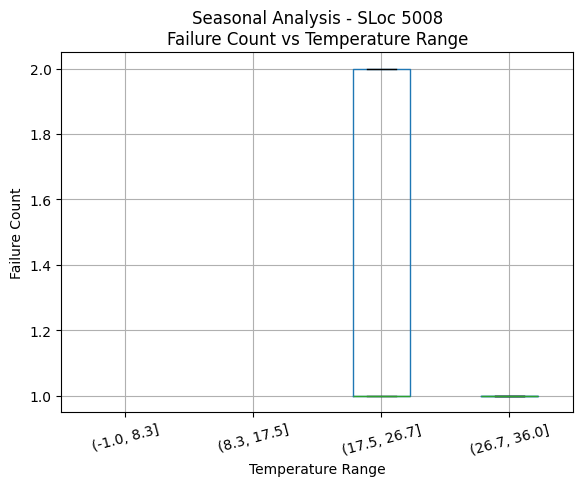


SLOC : 5009


<Figure size 1000x600 with 0 Axes>

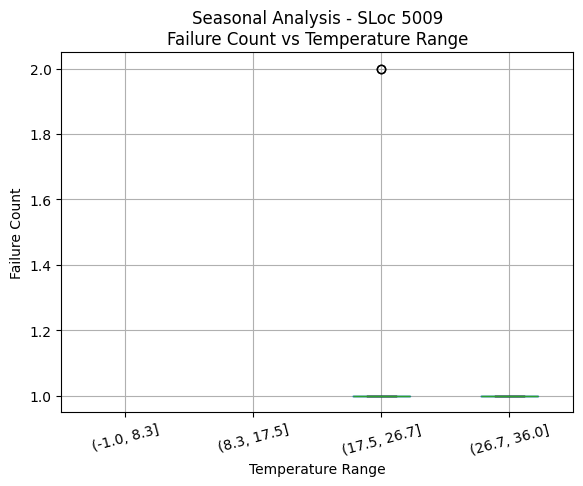


SLOC : 5010


<Figure size 1000x600 with 0 Axes>

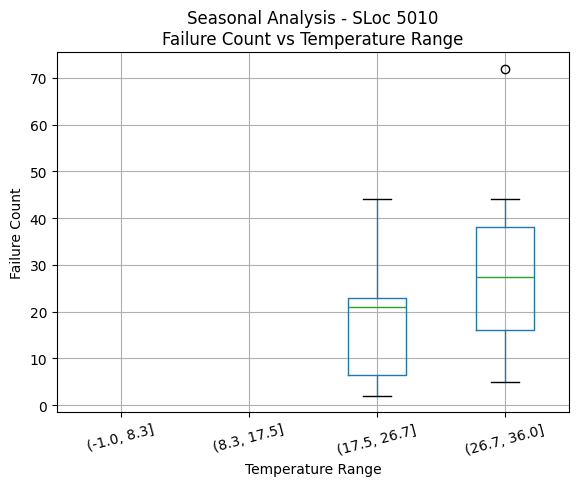


SLOC : 5011


<Figure size 1000x600 with 0 Axes>

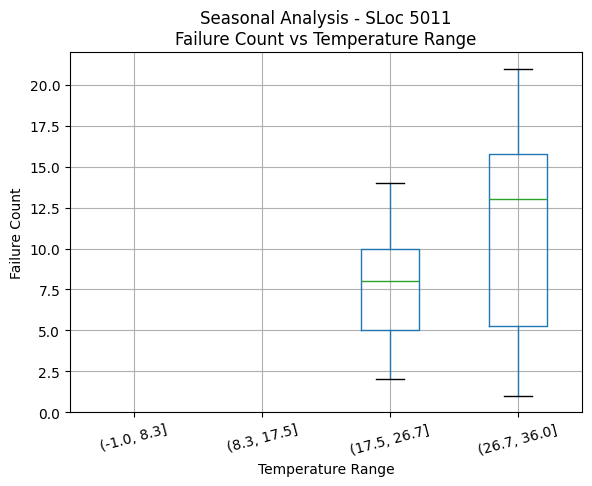


SLOC : 5014


<Figure size 1000x600 with 0 Axes>

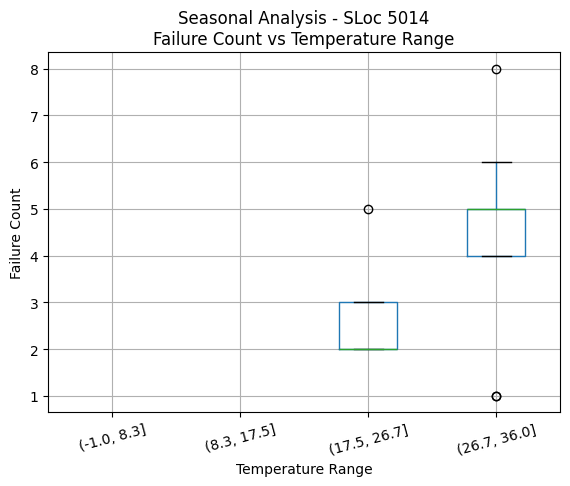


SLOC : 5021


<Figure size 1000x600 with 0 Axes>

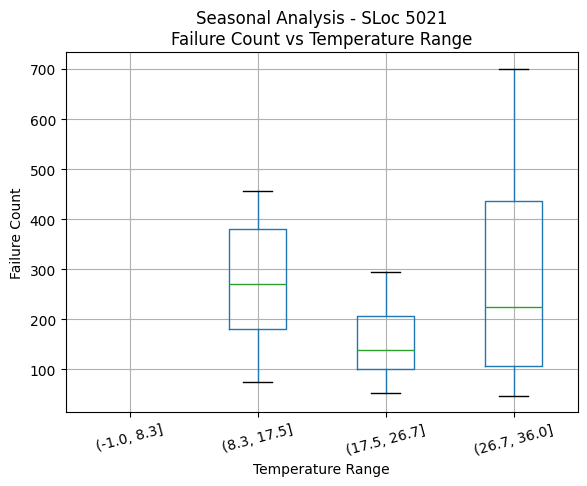


SLOC : 5022


<Figure size 1000x600 with 0 Axes>

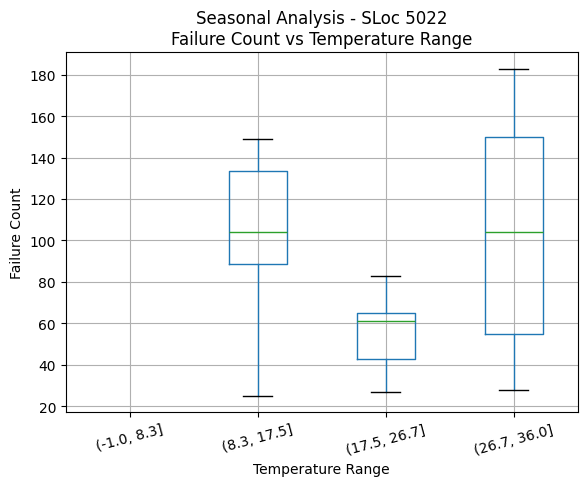


SLOC : 5023


<Figure size 1000x600 with 0 Axes>

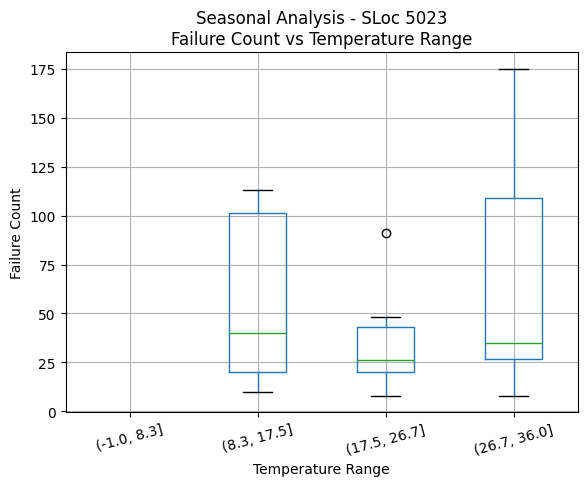


SLOC : 5024


<Figure size 1000x600 with 0 Axes>

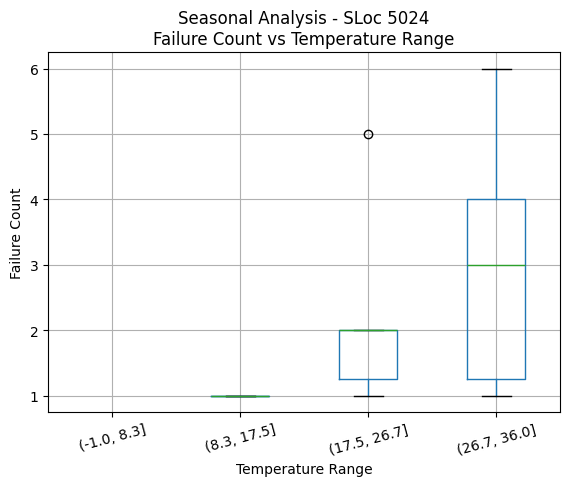


SLOC : 5025


<Figure size 1000x600 with 0 Axes>

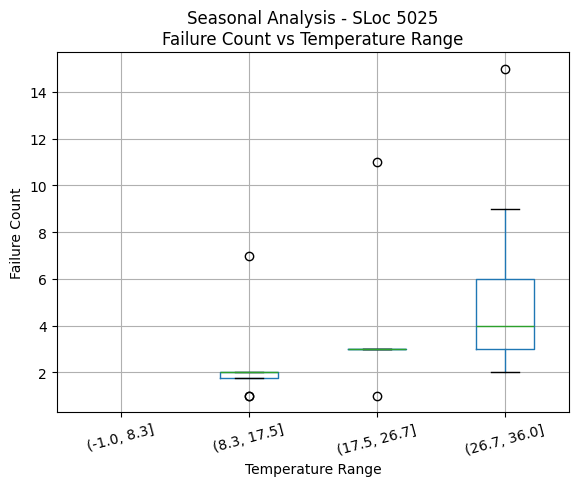


SLOC : 5026
Constant values detected

SLOC : 5027
Constant values detected

SLOC : 5028


<Figure size 1000x600 with 0 Axes>

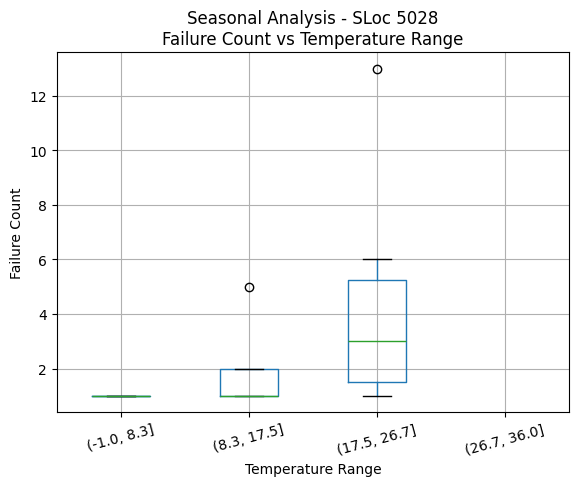


SLOC : 5029


<Figure size 1000x600 with 0 Axes>

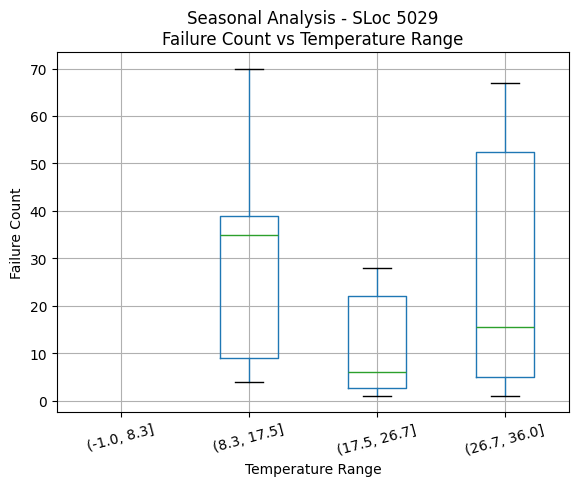


SLOC : 5030


<Figure size 1000x600 with 0 Axes>

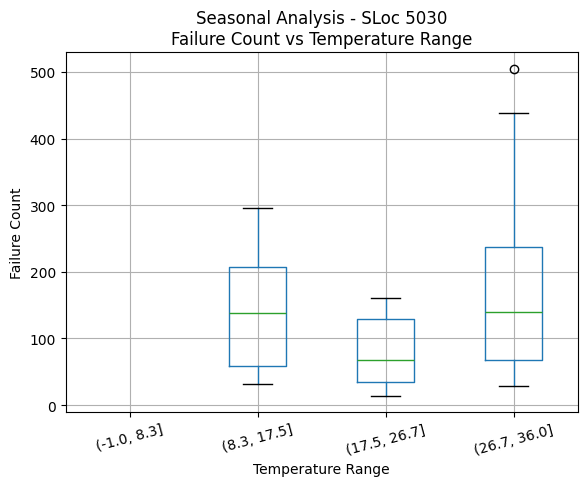


SLOC : 5031


<Figure size 1000x600 with 0 Axes>

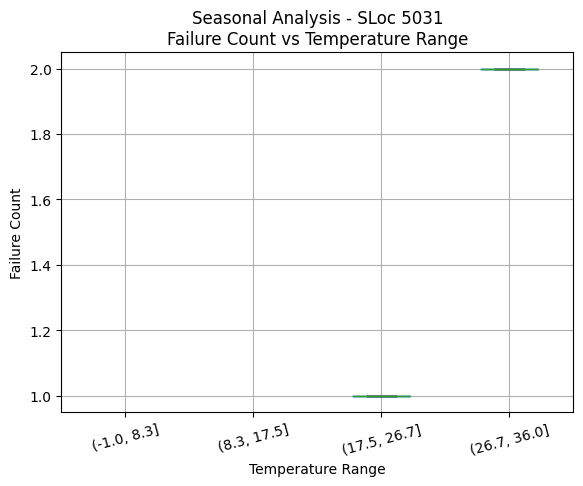


SLOC : 5032


<Figure size 1000x600 with 0 Axes>

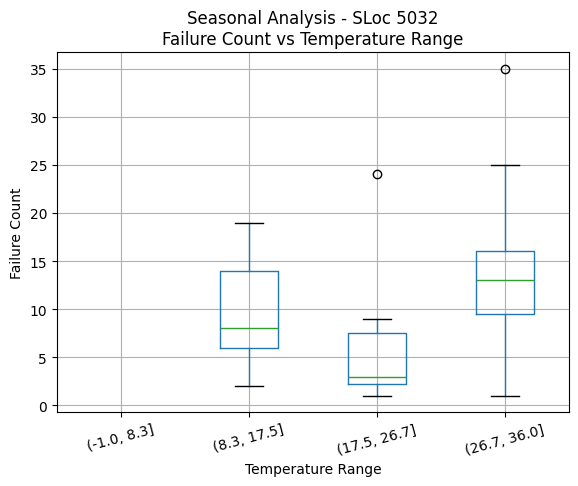


SLOC : 5033


<Figure size 1000x600 with 0 Axes>

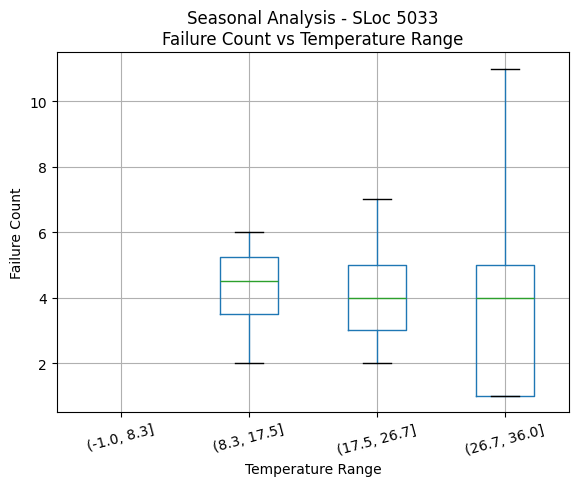


SLOC : 5036


<Figure size 1000x600 with 0 Axes>

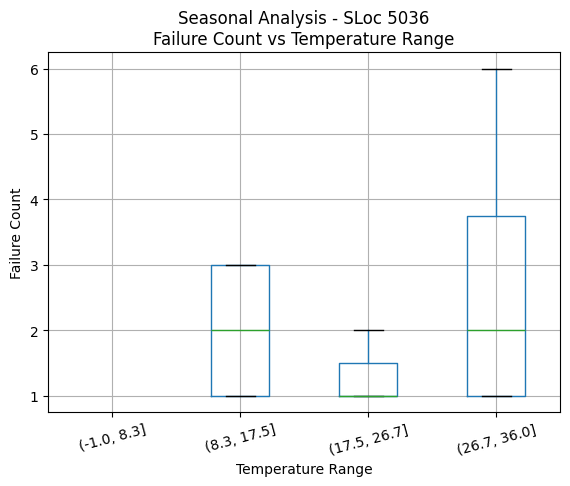


SLOC : 5039


<Figure size 1000x600 with 0 Axes>

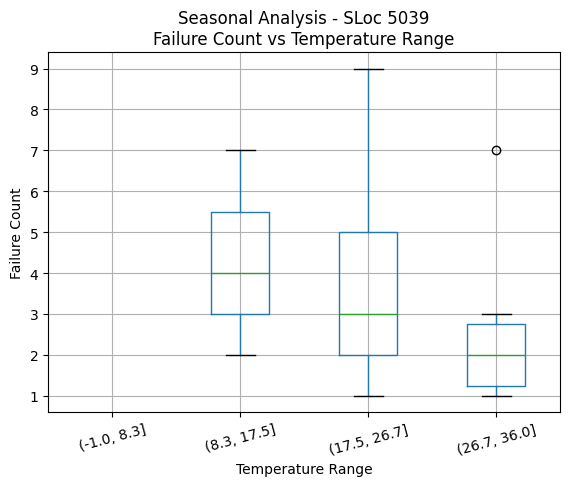


SLOC : 5041


<Figure size 1000x600 with 0 Axes>

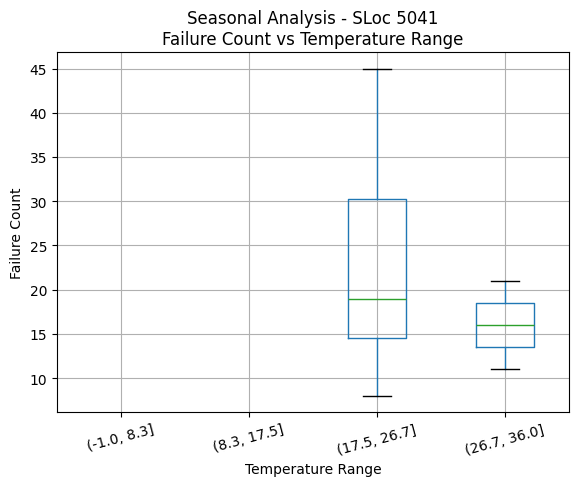


SLOC : 5042


<Figure size 1000x600 with 0 Axes>

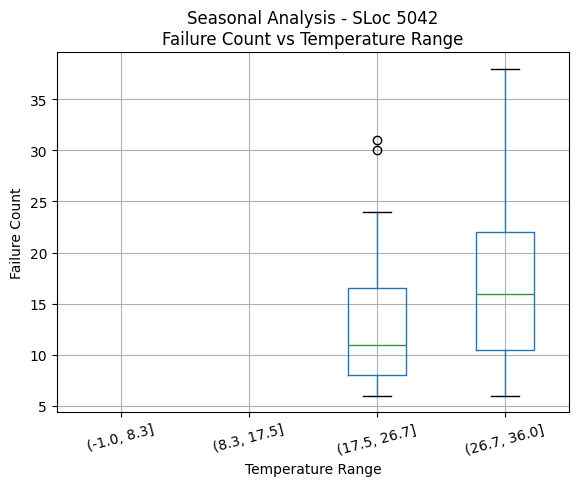


SLOC : 5043


<Figure size 1000x600 with 0 Axes>

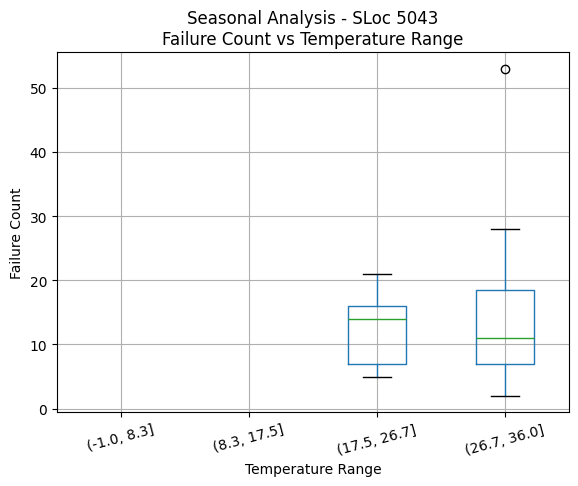


SLOC : 5044


<Figure size 1000x600 with 0 Axes>

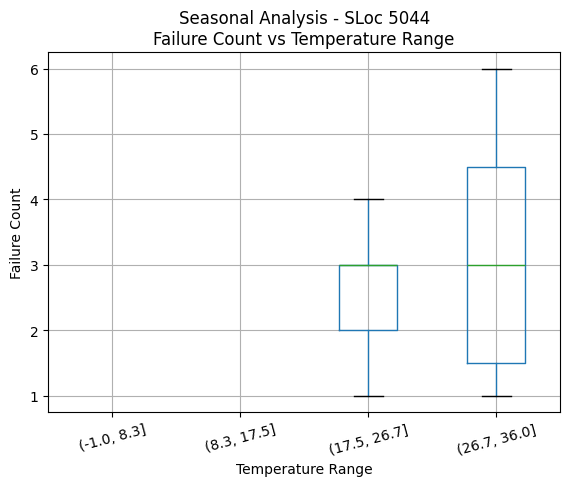


SLOC : 5046


<Figure size 1000x600 with 0 Axes>

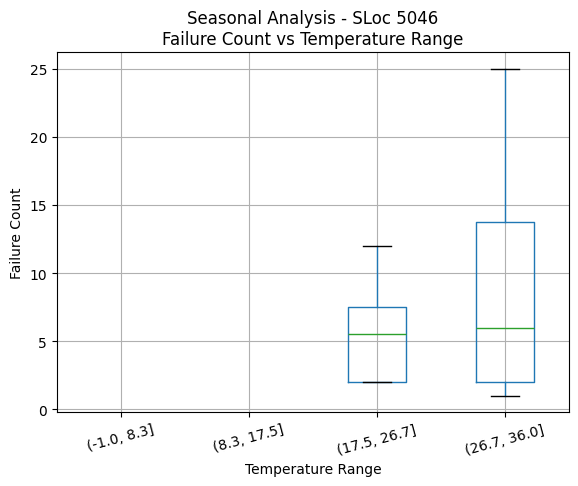


SLOC : 5049


<Figure size 1000x600 with 0 Axes>

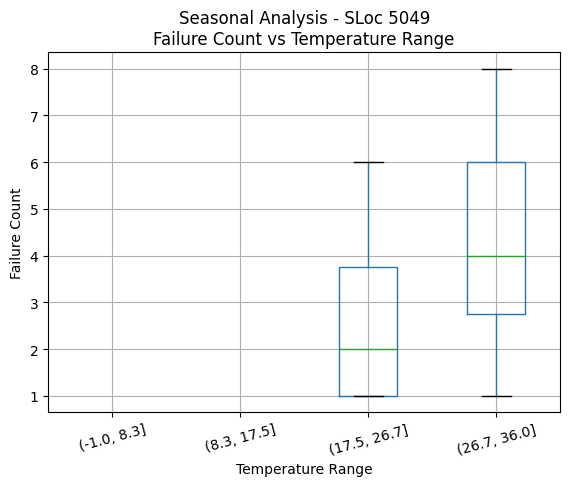


SLOC : 5052


<Figure size 1000x600 with 0 Axes>

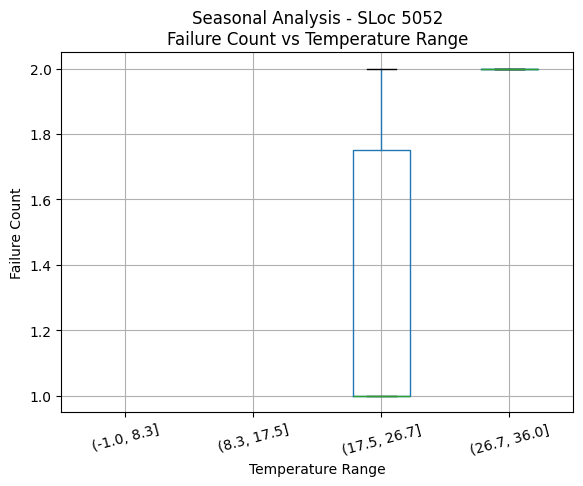


SLOC : 5061


<Figure size 1000x600 with 0 Axes>

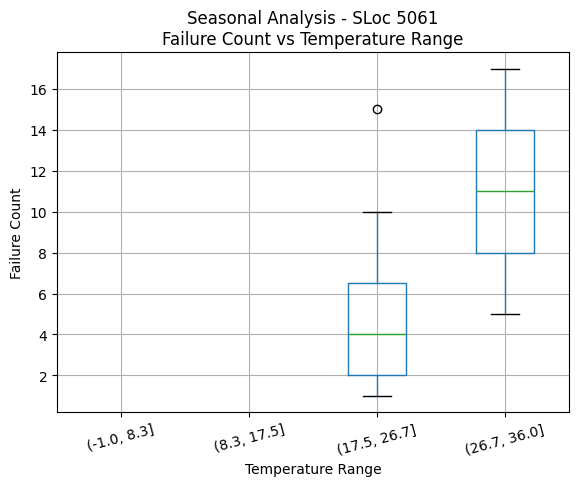


SLOC : 5062
Constant values detected

SLOC : 5063


<Figure size 1000x600 with 0 Axes>

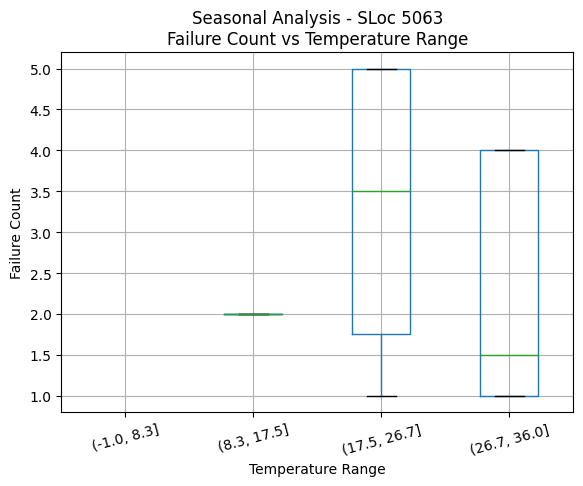


SLOC : 5064


<Figure size 1000x600 with 0 Axes>

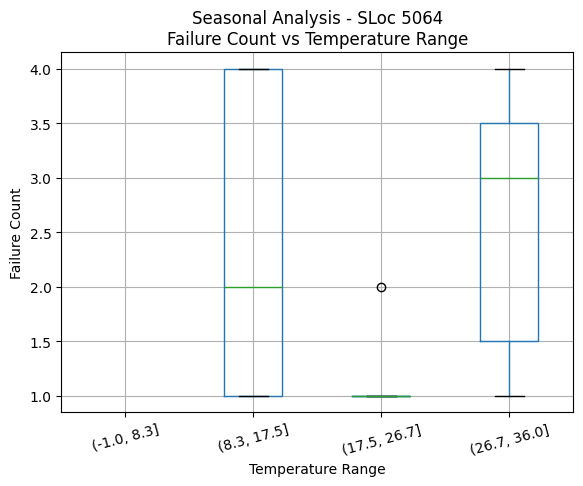


SLOC : 509A


<Figure size 1000x600 with 0 Axes>

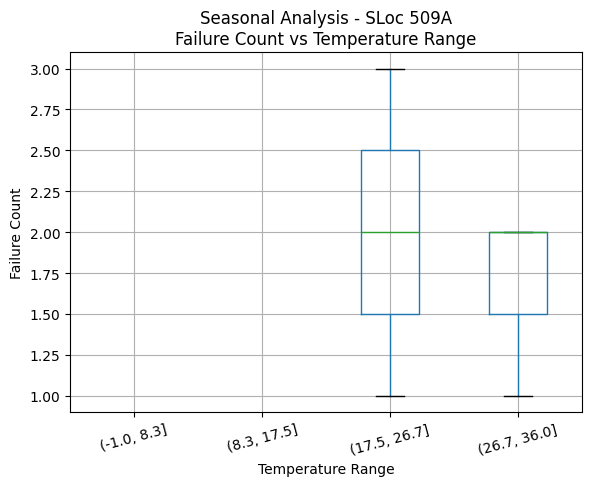


SLOC : 50BK


<Figure size 1000x600 with 0 Axes>

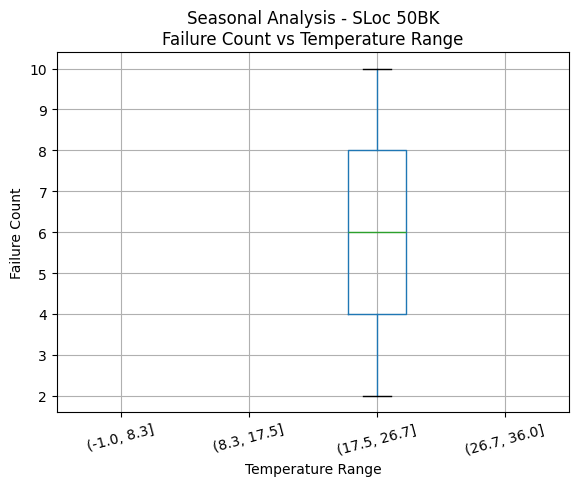


SLOC : 50TC


<Figure size 1000x600 with 0 Axes>

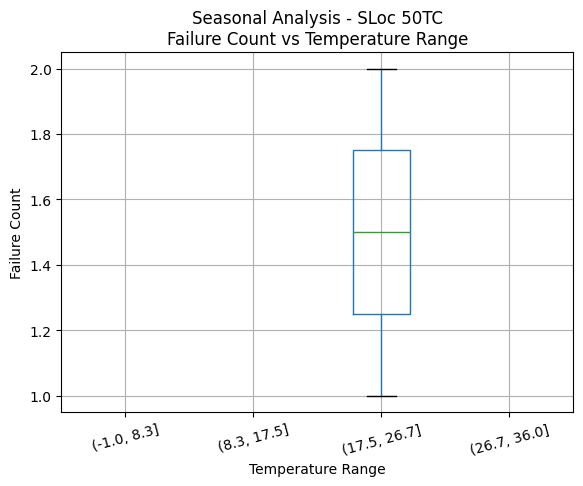


SEASONAL SLOC-WISE ANALYSIS COMPLETED
ALL RESULTS EXPORTED SUCCESSFULLY


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau,
    f_oneway,
    kruskal,
    chi2_contingency
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import os

# ==========================================
# CREATE OUTPUT DIRECTORY
# ==========================================

output_dir = r"Temperature_Analysis\Seasonal_Analysis\SLoc-Wise"

os.makedirs(output_dir, exist_ok=True)

# ==========================================
# LOAD TEMPERATURE DATASET
# ==========================================

temp_df = pd.read_excel(
    r"C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Temperature_And_Quantity_Analysis.xlsx",
    sheet_name='Temp_Season_SLoc'
)

# ==========================================
# LOAD FAILURE DATASET
# ==========================================

failure_df = pd.read_excel(
    r"C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Temperature_And_Quantity_Analysis.xlsx",
    sheet_name='Qty_Season_SLoc'
)

# ==========================================
# MERGE DATASETS
# ==========================================

df = pd.merge(
    temp_df,
    failure_df,
    on=['SLoc', 'Year', 'Season'],
    how='inner'
)

# ==========================================
# RENAME COLUMNS
# ==========================================

df.rename(columns={
    'Avg_Temperature': 'Avg_Temp',
    'Absolute_Quantity': 'Failure_Count'
}, inplace=True)

# ==========================================
# CLEAN SLoc COLUMN
# ==========================================

df['SLoc'] = (
    df['SLoc']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
    .str.upper()
)

# ==========================================
# CLEAN SEASON COLUMN
# ==========================================

df['Season'] = (
    df['Season']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
    .str.upper()
)

# ==========================================
# CREATE TEMPERATURE RANGES
# ==========================================

df['Temp_Range'] = pd.cut(
    df['Avg_Temp'],
    bins=4,
    precision=1
)

# ==========================================
# CREATE FAILURE CATEGORIES
# ==========================================

df['Failure_Category'] = pd.cut(
    df['Failure_Count'],
    bins=4,
    labels=[
        'LOW',
        'MODERATE',
        'HIGH',
        'VERY_HIGH'
    ]
)

# ==========================================
# DISPLAY DATA
# ==========================================

print(df.head())

# ==========================================
# STORE RESULTS
# ==========================================

pearson_results = []
spearman_results = []
kendall_results = []
anova_results = []
kruskal_results = []
chi_results = []
cramers_results = []
tukey_all_results = []

# ==========================================
# SLOC LIST
# ==========================================

slocs = df['SLoc'].unique()

# ==========================================
# LOOP THROUGH EACH SLOC
# ==========================================

for sloc in slocs:

    print(f"\n==============================")
    print(f"SLOC : {sloc}")
    print(f"==============================")

    sloc_df = df[df['SLoc'] == sloc]

    # ======================================
    # CHECK DATA VALIDITY
    # ======================================

    if len(sloc_df) < 2:
        print("Not enough data")
        continue

    if (
        sloc_df['Avg_Temp'].nunique() <= 1 or
        sloc_df['Failure_Count'].nunique() <= 1
    ):
        print("Constant values detected")
        continue

    # ======================================
    # PEARSON CORRELATION
    # ======================================

    pearson_corr, pearson_p = pearsonr(
        sloc_df['Avg_Temp'],
        sloc_df['Failure_Count']
    )

    pearson_results.append({
        'SLoc': sloc,
        'Pearson_Correlation': round(pearson_corr, 4),
        'P_Value': round(pearson_p, 6)
    })

    # ======================================
    # SPEARMAN CORRELATION
    # ======================================

    spearman_corr, spearman_p = spearmanr(
        sloc_df['Avg_Temp'],
        sloc_df['Failure_Count']
    )

    spearman_results.append({
        'SLoc': sloc,
        'Spearman_Correlation': round(spearman_corr, 4),
        'P_Value': round(spearman_p, 6)
    })

    # ======================================
    # KENDALL TAU
    # ======================================

    kendall_corr, kendall_p = kendalltau(
        sloc_df['Avg_Temp'],
        sloc_df['Failure_Count']
    )

    kendall_results.append({
        'SLoc': sloc,
        'Kendall_Tau': round(kendall_corr, 4),
        'P_Value': round(kendall_p, 6)
    })

    # ======================================
    # CREATE GROUPS FOR ANOVA/KRUSKAL
    # ======================================

    groups = []

    temp_ranges = sloc_df['Temp_Range'].unique()

    for temp_range in temp_ranges:

        group_data = sloc_df[
            sloc_df['Temp_Range'] == temp_range
        ]['Failure_Count']

        if len(group_data) < 2:
            continue

        groups.append(group_data)

    # ======================================
    # ANOVA
    # ======================================

    if len(groups) >= 2:

        anova_f, anova_p = f_oneway(*groups)

        anova_results.append({
            'SLoc': sloc,
            'F_Statistic': round(anova_f, 4),
            'P_Value': round(anova_p, 6)
        })

        # ==================================
        # KRUSKAL WALLIS
        # ==================================

        kruskal_h, kruskal_p = kruskal(*groups)

        kruskal_results.append({
            'SLoc': sloc,
            'H_Statistic': round(kruskal_h, 4),
            'P_Value': round(kruskal_p, 6)
        })

        # ==================================
        # TUKEY HSD
        # ==================================

        try:

            tukey = pairwise_tukeyhsd(
                endog=sloc_df['Failure_Count'],
                groups=sloc_df['Temp_Range'],
                alpha=0.05
            )

            tukey_df = pd.DataFrame(
                data=tukey._results_table.data[1:],
                columns=tukey._results_table.data[0]
            )

            tukey_df['SLoc'] = sloc

            tukey_all_results.append(tukey_df)

        except:
            print(f"Tukey failed for {sloc}")

    # ======================================
    # CHI SQUARE + CRAMER'S V
    # ======================================

    contingency_table = pd.crosstab(
        sloc_df['Temp_Range'],
        sloc_df['Failure_Category']
    )

    if (
        contingency_table.shape[0] >= 2 and
        contingency_table.shape[1] >= 2
    ):

        chi2, chi_p, dof, expected = chi2_contingency(
            contingency_table
        )

        chi_results.append({
            'SLoc': sloc,
            'Chi2_Statistic': round(chi2, 4),
            'P_Value': round(chi_p, 6),
            'Degrees_of_Freedom': dof
        })

        # ==================================
        # CRAMER'S V
        # ==================================

        n = contingency_table.sum().sum()

        min_dimension = min(
            contingency_table.shape[0] - 1,
            contingency_table.shape[1] - 1
        )

        cramers_v = np.sqrt(
            chi2 / (n * min_dimension)
        )

        cramers_results.append({
            'SLoc': sloc,
            'Cramers_V': round(cramers_v, 4),
            'P_Value': round(chi_p, 6)
        })

    # ======================================
    # BOXPLOT
    # ======================================

    plt.figure(figsize=(10,6))

    sloc_df.boxplot(
        column='Failure_Count',
        by='Temp_Range',
        rot=15
    )

    plt.title(
        f"Seasonal Analysis - SLoc {sloc}\n"
        f"Failure Count vs Temperature Range"
    )

    plt.suptitle("")

    plt.xlabel("Temperature Range")
    plt.ylabel("Failure Count")

    plt.grid(True)

    plt.show()

# ==========================================
# CONVERT TO DATAFRAMES
# ==========================================

pearson_df = pd.DataFrame(pearson_results)
spearman_df = pd.DataFrame(spearman_results)
kendall_df = pd.DataFrame(kendall_results)
anova_df = pd.DataFrame(anova_results)
kruskal_df = pd.DataFrame(kruskal_results)
chi_df = pd.DataFrame(chi_results)
cramers_df = pd.DataFrame(cramers_results)

# ==========================================
# TUKEY DATAFRAME
# ==========================================

if len(tukey_all_results) > 0:

    tukey_df_final = pd.concat(
        tukey_all_results,
        ignore_index=True
    )

else:

    tukey_df_final = pd.DataFrame()

# ==========================================
# EXPORT RESULTS
# ==========================================

pearson_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Pearson.xlsx",
    index=False
)

spearman_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Spearman.xlsx",
    index=False
)

kendall_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Kendall.xlsx",
    index=False
)

anova_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_ANOVA.xlsx",
    index=False
)

kruskal_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Kruskal.xlsx",
    index=False
)

tukey_df_final.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Tukey_HSD.xlsx",
    index=False
)

chi_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Chi_Square.xlsx",
    index=False
)

cramers_df.to_excel(
    rf"{output_dir}\Seasonal_SLocwise_Cramers_V.xlsx",
    index=False
)

print("\n===================================")
print("SEASONAL SLOC-WISE ANALYSIS COMPLETED")
print("ALL RESULTS EXPORTED SUCCESSFULLY")
print("===================================")